# **End-to-End E-commerce Analytics: Revenue, Retention & Customer Insights** 

## Business Problem

This project analyzes transactional data from a UK-based online retail company to:

- Understand revenue trends
- Identify high-value customers
- Analyze customer retention
- Detect key drop-offs in the purchase lifecycle

Goal: Provide actionable insights to improve revenue and retention.

## Understanding Data
This dataset contains transactional records of a UK-based online retail company for the period between December 2010 and December 2011. Each row represents a unique product purchased within an invoice, capturing details such as invoice number, product information, quantity, price, customer identifier, and country of purchase. The data provides a comprehensive view of sales activity across customers and regions, making it suitable for analyzing revenue trends, customer behavior, and purchasing patterns.

However, the dataset requires careful preprocessing due to several data quality issues. A significant number of records have missing Customer IDs, which limits customer-level analysis. Additionally, some transactions contain negative quantities, representing product returns. Invoice numbers numbers starting with “C” are treated as cancelled transactions based on observed patterns in the data, as they are consistently associated with negative quantities (returns). These factors need to be addressed during the data cleaning phase to ensure accurate and meaningful analysis.


## Data Cleaning

The dataset contains several inconsistencies that need to be addressed before analysis.

- Records with missing Customer IDs are removed, as they cannot be linked to unique users and would impact customer-level analysis such as retention and segmentation.
- Transactions with invoice numbers starting with "C" are treated as cancelled orders, as they are consistently associated with negative quantities.
- Negative quantities are removed since they represent product returns and do not reflect actual sales.
- The InvoiceDate column is converted to a datetime format to enable time-based analysis.

These steps ensure that the dataset reflects valid purchase transactions and supports accurate business insights.

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/carrie1/ecommerce-data/data.csv',encoding='ISO-8859-1')

# Keep a copy of raw data
raw_df = df.copy()

print("Original Shape:", df.shape)
print("Missing CustomerID Count:", df['CustomerID'].isna().sum())
print("Cancelled invoices Count:", df['InvoiceNo'].astype(str).str.startswith('C').sum())
print("Negative quantities records:", (df['Quantity'] < 0).sum())

# 1. Remove missing CustomerID

df = df.dropna(subset=['CustomerID'])

# Convert CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

# 2. Remove cancelled invoices

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 3. Remove negative quantities

df = df[df['Quantity'] > 0]

# 4. Convert InvoiceDate to datetime

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Final shape

print("After Cleaning:", df.shape)

# Save cleaned dataset
df.to_csv('/kaggle/working/cleaned_ecommerce_data.csv', index=False)

print("Cleaned dataset saved successfully!")

Original Shape: (541909, 8)
Missing CustomerID Count: 135080
Cancelled invoices Count: 9288
Negative quantities records: 10624
After Cleaning: (397924, 8)
Cleaned dataset saved successfully!


## Feature Engineering

To enable deeper analysis, new features are created from the existing transactional data.

- TotalPrice is calculated to represent the revenue generated per transaction.
- InvoiceMonth is extracted to analyze monthly trends.
- Customer Lifetime is computed to understand how long a customer remains active.
- Order Frequency is derived to measure customer engagement.

Additionally, RFM (Recency, Frequency, Monetary) metrics are created to segment customers based on purchasing behavior.


In [2]:
# Total revenue per row
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
# Extract year-month for trend analysis
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
# Reference date (latest date in dataset)
snapshot_date = df['InvoiceDate'].max()

# Group by customer
customer_df = df.groupby('CustomerID').agg({
    'InvoiceDate': [lambda x: (snapshot_date - x.max()).days,   # Recency
                    lambda x: (x.max() - x.min()).days],       # Customer Lifetime
    'InvoiceNo': 'nunique',                                    # Frequency
    'TotalPrice': 'sum'                                        # Monetary
})
customer_df.columns = ['Recency', 'Customer_Lifetime', 'Frequency', 'Monetary']
customer_df = customer_df.reset_index()
# Orders per day (engagement metric)
customer_df['Order_Frequency'] = customer_df['Frequency'] / (customer_df['Customer_Lifetime'] + 1)


### RFM Metrics

- Recency: Number of days since the customer’s last purchase (lower is better)
- Frequency: Total number of unique purchases made by the customer
- Monetary: Total revenue generated by the customer

These metrics are widely used to identify high-value customers and segment users based on behavior.

In [3]:
# Create RFM scores using quartiles 
customer_df['R_score'] = pd.qcut(customer_df['Recency'], 4, labels=[4,3,2,1])
customer_df['F_score'] = pd.qcut(customer_df['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
customer_df['M_score'] = pd.qcut(customer_df['Monetary'], 4, labels=[1,2,3,4]) 
# Combine scores

customer_df['RFM_Score'] = (
    customer_df['R_score'].astype(str) +
    customer_df['F_score'].astype(str) +
    customer_df['M_score'].astype(str)
)

In [4]:
# Convert R, F, M scores to integers
customer_df['R_score'] = customer_df['R_score'].astype(int)
customer_df['F_score'] = customer_df['F_score'].astype(int)
customer_df['M_score'] = customer_df['M_score'].astype(int)

# Correct total score (SUM, not string conversion)
customer_df['RFM_Score_Total'] = (
    customer_df['R_score'] + 
    customer_df['F_score'] + 
    customer_df['M_score']
)

# Create top customers dataframe
top_customers = customer_df.sort_values(
    by=['RFM_Score_Total', 'Monetary'], 
    ascending=False
).head(10)

# Display
top_customers[['CustomerID', 'R_score', 'F_score', 'M_score', 
               'RFM_Score_Total', 'Monetary']]

,CustomerID,R_score,F_score,M_score,RFM_Score_Total,Monetary
1690,14646,4,4,4,12,280206.02
4202,18102,4,4,4,12,259657.30
3729,17450,4,4,4,12,194550.79
1880,14911,4,4,4,12,143825.06
1334,14156,4,4,4,12,117379.63
3772,17511,4,4,4,12,91062.38
3177,16684,4,4,4,12,66653.56
1290,14096,4,4,4,12,65164.79
997,13694,4,4,4,12,65039.62
2177,15311,4,4,4,12,60767.90


### Top Customer Insights

The top 10 customers all have the highest possible RFM score (12), indicating that they are recent, frequent, and high-spending customers. These customers represent the most valuable segment and contribute significantly to overall revenue.

A small number of customers generate a disproportionately high amount of revenue, highlighting the importance of retaining and nurturing this segment.

The revenue contribution from top customers is significantly higher compared to the average customer, indicating a strong revenue concentration among a small subset of users (Pareto principle).

## KPI Analysis

Key performance indicators are analyzed to understand overall business performance, including revenue trends, customer purchasing behavior, and product-level insights.

In [5]:
# Total Revenue
total_revenue = df['TotalPrice'].sum()
print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 8911407.9


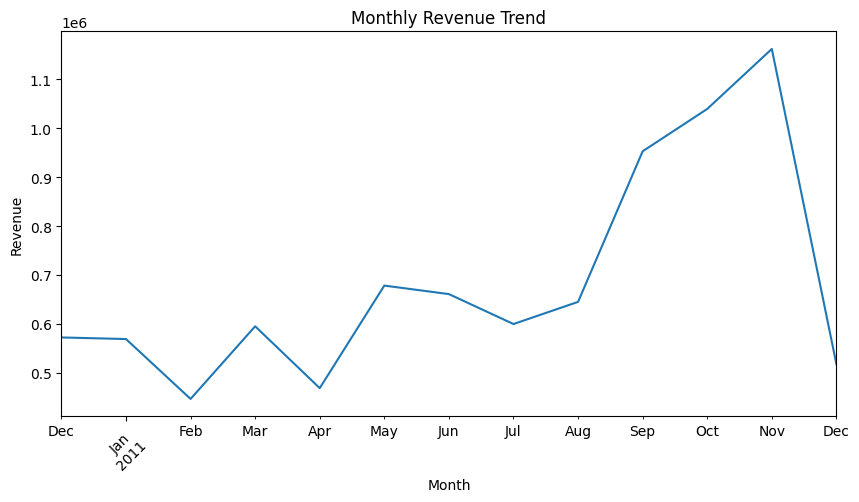

In [6]:
# Monthly Revenue Trend
monthly_revenue = df.groupby('InvoiceMonth')['TotalPrice'].sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [7]:
# Revenue per invoice
invoice_data = df.groupby('InvoiceNo')['TotalPrice'].sum()
# Average Order Value
AOV = invoice_data.mean()
print("Average Order Value (AOV):", round(AOV, 2))

Average Order Value (AOV): 480.76


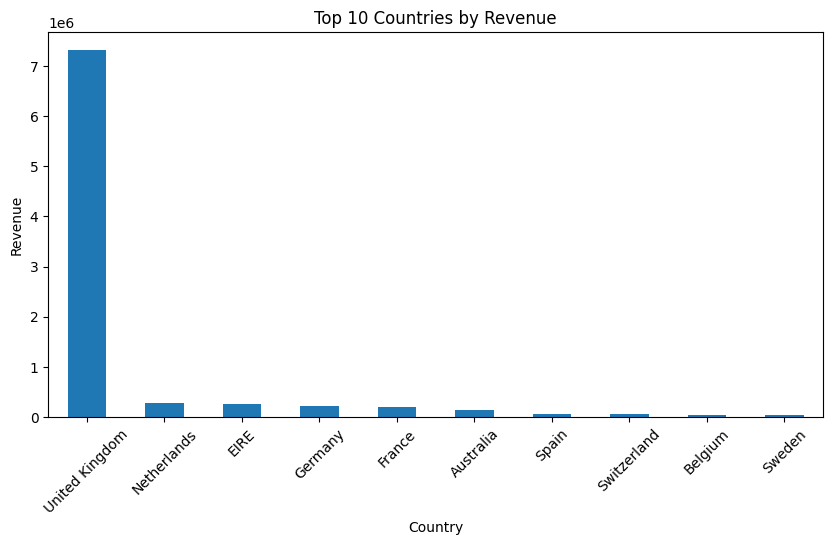

In [8]:
# Top Countries
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

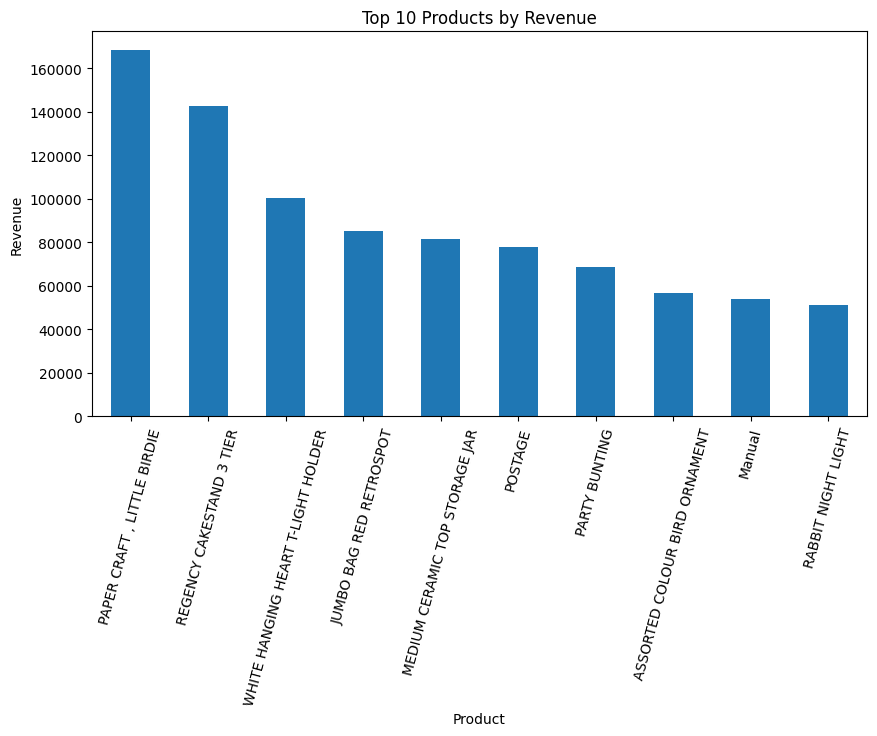

In [9]:
# Top Products
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=75)
plt.show()

## Customer Analysis

Customer-level metrics are analyzed to understand purchasing behavior, retention, and revenue contribution.

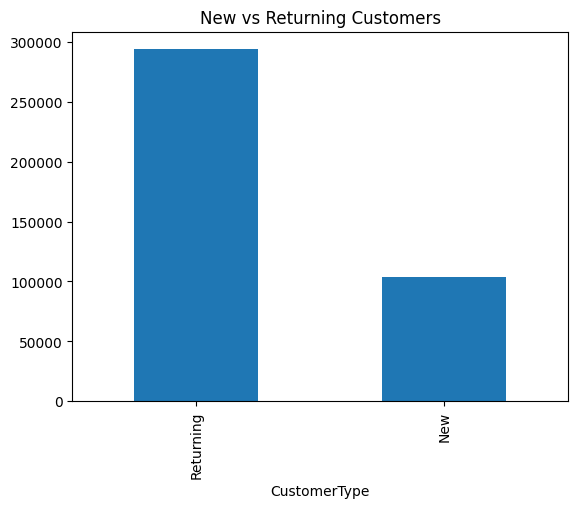

In [10]:
# First purchase per customer
first_purchase = df.groupby('CustomerID')['InvoiceDate'].min().reset_index()
first_purchase.columns = ['CustomerID', 'FirstPurchaseDate']

# Merge back
df = df.merge(first_purchase, on='CustomerID', how='left')

# Label customers
df['CustomerType'] = df['InvoiceDate'] == df['FirstPurchaseDate']
df['CustomerType'] = df['CustomerType'].map({True: 'New', False: 'Returning'})

# Count
customer_counts = df['CustomerType'].value_counts()

customer_counts.plot(kind='bar')
plt.title("New vs Returning Customers")
plt.show()

In [11]:
# Repeat Purchase Rate
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()

repeat_customers = (customer_orders > 1).sum()
total_customers = customer_orders.count()

repeat_rate = repeat_customers / total_customers
print("Repeat Purchase Rate:", round(repeat_rate * 100, 2), "%")

Repeat Purchase Rate: 65.57 %


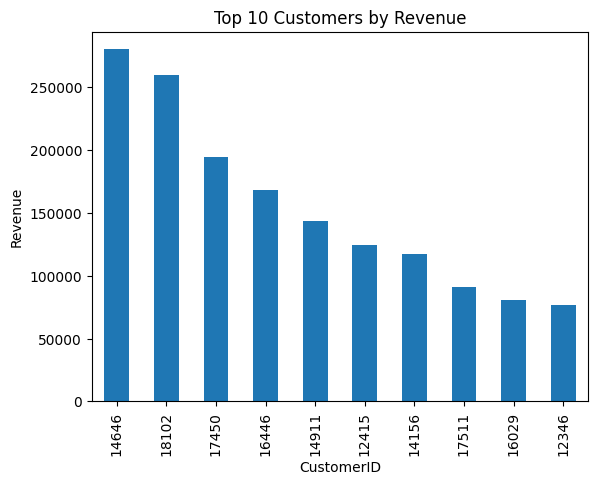

In [12]:
# Top 10 Customers by Revenue
top_customers_rev = df.groupby('CustomerID')['TotalPrice'].sum() \
                      .sort_values(ascending=False).head(10)

top_customers_rev.plot(kind='bar')
plt.title("Top 10 Customers by Revenue")
plt.xlabel("CustomerID")
plt.ylabel("Revenue")
plt.show()

### Customer Insights

A small percentage of customers contributes to a large portion of total revenue, indicating a strong revenue concentration among high-value users.

## Cohort Analysis

Cohort analysis groups customers based on their first purchase month and tracks their retention over time. This helps in understanding customer behavior, identifying retention patterns, and evaluating long-term engagement.

Each cohort represents a group of customers acquired in the same month, and retention is measured as the percentage of customers who continue to make purchases in subsequent months.

In [13]:
# Create a copy
cohort_df = df.copy()

# Create InvoiceMonth
cohort_df['InvoiceMonth'] = cohort_df['InvoiceDate'].dt.to_period('M')

# Create CohortMonth (first purchase month per customer)
cohort_df['CohortMonth'] = cohort_df.groupby('CustomerID')['InvoiceDate'] \
                                    .transform('min') \
                                    .dt.to_period('M')

# Function to calculate month difference
def get_month_index(df):
    return (df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year) * 12 + \
           (df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month)

cohort_df['CohortIndex'] = get_month_index(cohort_df)
# Group data
cohort_data = cohort_df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'] \
                       .nunique() \
                       .reset_index()

# Pivot table
cohort_pivot = cohort_data.pivot(index='CohortMonth', 
                                columns='CohortIndex', 
                                values='CustomerID')
# Divide by first column (cohort size)
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)

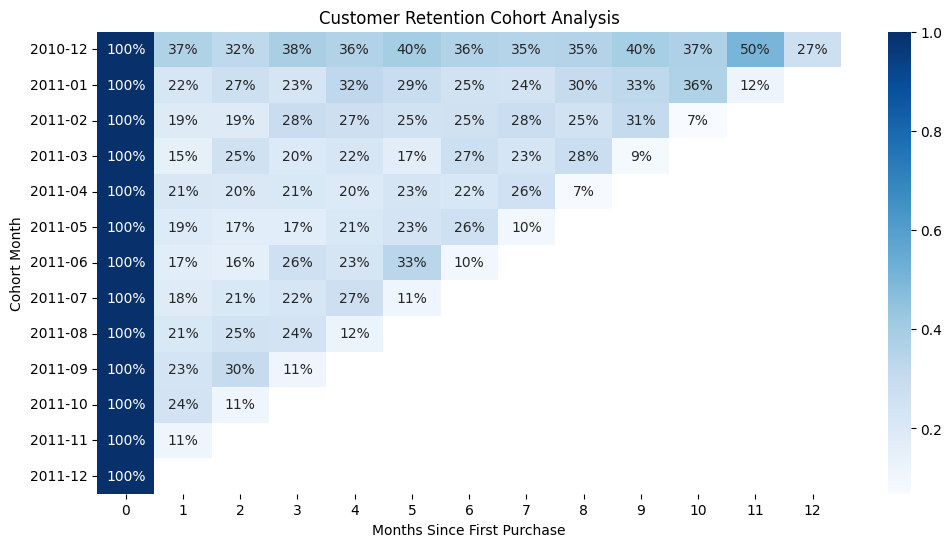

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Customer Retention Cohort Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()

### Key Insights from Cohort Analysis

- Customer retention drops significantly after the first month across almost all cohorts. Most cohorts retain only ~15–25% of users in month 1, indicating that a large proportion of customers do not return after their initial purchase.
- Early cohorts (Dec 2010 – Jan 2011) show relatively stronger long-term retention compared to later cohorts. For example, the Dec 2010 cohort maintains ~35–50% retention even after several months, suggesting higher customer loyalty during this period.
- Retention stabilizes after the initial drop, with repeat customers showing consistent engagement over time. This indicates that once customers make multiple purchases, they are more likely to continue purchasing.
- Several cohorts (e.g., Mar–May 2011) show sharp declines in retention within the first 2–3 months, highlighting potential issues in customer onboarding or post-purchase engagement.
- Later cohorts (Sep–Nov 2011) show lower retention levels overall, which may indicate declining customer quality, seasonal effects, or changes in business strategy.
- A few spikes in retention (e.g., Dec 2010 cohort around month 11) suggest seasonal effects, likely driven by holiday purchasing behavior.


## Key Insights

The following insights are derived from exploratory data analysis and customer behavior patterns observed in the dataset.

- Revenue shows strong seasonality, with a significant spike during November and December. This suggests that sales are highly influenced by holiday demand, making this period critical for revenue generation.

- Customer retention is low, with a sharp drop observed after the first purchase. Cohort analysis indicates that a majority of customers do not return, highlighting a gap in early-stage customer engagement.

- A small percentage of customers contributes disproportionately to total revenue. RFM analysis shows that top customers (high Recency, Frequency, and Monetary scores) generate a large share of revenue.

- Repeat purchase rate is relatively low, indicating that most customers make only one or two purchases. This suggests an opportunity to improve customer loyalty and lifetime value.

- Certain products and countries contribute significantly more to revenue, indicating potential areas for focused marketing and inventory optimization.

- Long-term customers exhibit stable purchasing behavior once they pass the initial drop-off phase, suggesting that converting first-time buyers into repeat customers can significantly improve overall performance.

- Overall, the analysis reveals that the business relies heavily on a small segment of high-value customers, while struggling with low retention among new users. Improving early customer engagement and retention could significantly increase long-term revenue.